In [63]:
using QuantumOptics
import PhysicalConstants.CODATA2018: c_0
using Unitful
using PyPlot
using LinearAlgebra
using JLD2

In [64]:
""" Return the minimum distance of a distribution of atoms r0 """
function min_r0(r0)
    N = length(r0)
    d0 = zeros(N, N) # Repetiton, atom i, distance from atom j
    for j in 1:N
        for k = 1:N
            d0[j, k] = norm(r0[j]-r0[k])
        end
    end
    return minimum(d0[d0 .> 0])
end

min_r0

### Parameters

In [65]:
# Nbr of particles
N = 10
n = 1

# Normalisation parameters
λ = 421e-9
γ = 32.7e6 # In Hz

# Physical values
ω0 = (2π*ustrip(c_0)/λ)
ωl = ω0
kl = [2π/λ, 0, 0] # Laser along x
Ω = 1e7 # Taken from Barbut arXiv:2412.02541v1

# Position of atoms
d0_lb = 5e-10 # Minimum distance between the atoms (lower boundary) in m

# Normalization
ω0 = ω0 / γ
ωl = ωl / γ
kl = kl * λ
Ω = Ω / γ
d0_lb = d0_lb / λ

# Integration parameter
tstep = 0.1
T = [0:tstep:10;]; # Normalised time

In [66]:
# Compute the distribution
L = (N/n)^(1/3) # Change the volume to keep the density cste
r0 = [[rand(Float64)*L, rand(Float64)*L, rand(Float64)*L] for i in 1:N]

# Choose a distribution where the minimum distance between the atoms is bigger than d0_min
while min_r0(r0) < d0_lb
    r0 = [[rand(Float64)*L, rand(Float64)*L, rand(Float64)*L] for i in 1:N]
end

# Save the atoms position for comparison with QuantumOptics
@save "r0/r0_N_$(N).jdl2" r0 L

### Parametrisation

In [67]:
# Basis
b1 = SpinBasis(1//2)

# One body operators
σp = sigmap(b1)
σm = sigmam(b1)
nup = σp*σm
ndown = σm*σp

# Many body operators
Jz = -8*ndown -9*nup; # 2 level system but GS has mJ = -8, ES has mJ = -9
J = [σm]; # Jump operator (SE)
Γ = 1. * Matrix(I, 1, 1)
Ψ0 = spindown(b1); # IS

# Without interactions

In [74]:
i=1
HRO = Ω * (exp(1im*r0[i]'kl)*σp + exp(-1im*r0[i]'kl)*σm)

Operator(dim=2x2)
  basis: Spin(1/2)
                      ⋅                      …  0.17720827064778621 - 0.2492332804138744im
 0.17720827064778621 + 0.2492332804138744im                          ⋅     

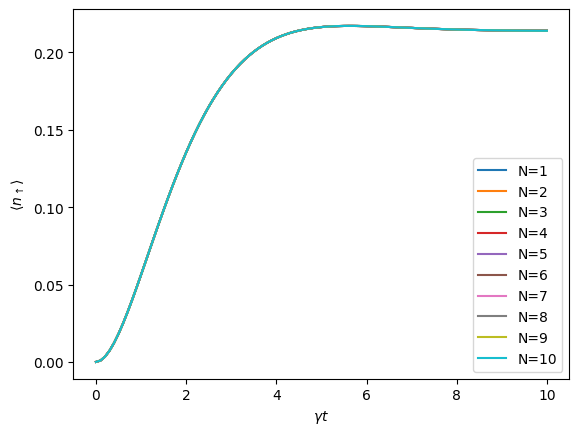

In [ ]:
close("all")
figure()

for i in 1:N
    HRO = Ω * (exp(1im*r0[i]'kl)*σp + exp(-1im*r0[i]'kl)*σm)
    ρt_indep_N = timeevolution.master(T, Ψ0, HRO, J; rates=Γ, dt=tstep)[2]
    plot(T, real(expect(nup, ρt_indep_N)), label="N=$i")
    
end
legend()
xlabel(L"$\gamma t$")
ylabel(L"$\langle  n_{\uparrow} \rangle $")
pygui(false); gcf()
# pygui(true); show()